# Evaluation Notebook for CIDR 2027 Submission

In [31]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np

from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
#from __future__ import annotations

In [32]:
# Settings from Andreas Zimmerer
def apply_plot_params(
    fig_height: float,
    scale: float = 1.0,
    double_column: bool = False,
) -> None:
    """Apply the standard publication plot settings."""

    mpl.rcParams.update(
        {
            "figure.figsize": (
                (7.00697 if double_column else 3.3374) * scale,
                fig_height * scale,
            ),
            "figure.dpi": 300,
            "font.size": 11.0,
            "font.family": "serif",
            "axes.titlesize": "medium",
            "figure.titlesize": "medium",
            "text.usetex": True,
            "text.latex.preamble": (
                r"\usepackage{amsmath}"
                r"\usepackage{amssymb}"
                r"\usepackage{siunitx}[=v2]"
            ),
            "pgf.rcfonts": False,
            "pgf.texsystem": "pdflatex", 
        }
    )
    mpl.rcdefaults()
    mpl.rcParams["text.usetex"] = False

    
reddish_cmap = LinearSegmentedColormap.from_list(
    "paper_reddish",
    [
        "#05051a",
        "#3b1f46",
        "#a61c5b",
        "#ef4444",
        "#f6c9ad",
        "#fff1e6",
    ]
)


apply_plot_params(fig_height=2.5, scale=1.0, double_column=False)

## Evaluation 1 - Error Rates per SuT

### Overview of SuT performance (all)

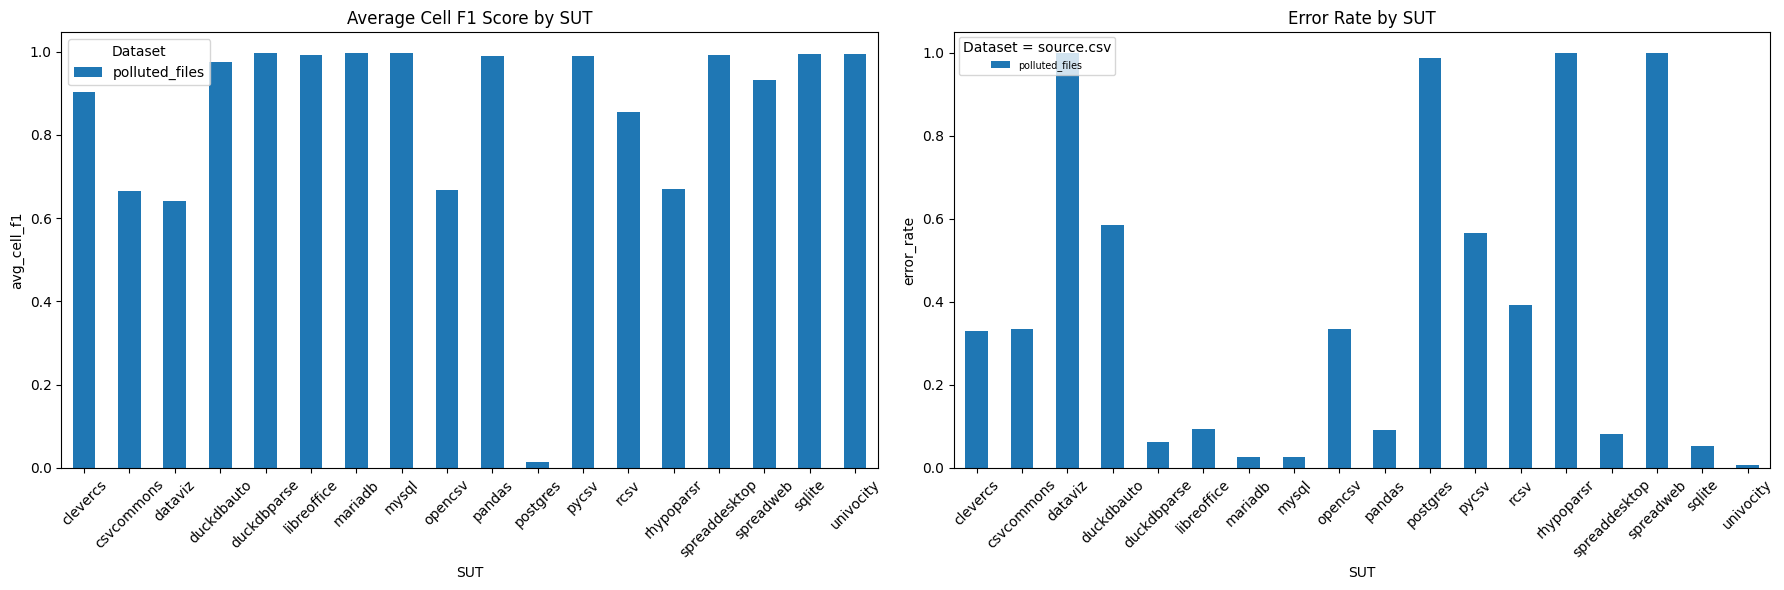

In [33]:
# Load CSV
df = pd.read_csv("../sut_error_summary.csv")

# Keep only summary rows
summary_df = df[df["pollution_group"] == "ALL"]

# Prepare pivot tables
pivot_f1 = summary_df.pivot(
    index="sut",
    columns="dataset",
    values="avg_cell_f1"
)

pivot_error = summary_df.pivot(
    index="sut",
    columns="dataset",
    values="error_rate"
)

# Create two plots next to each other
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 6)
)

# Plot 1: Average Cell F1 Score
pivot_f1.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Average Cell F1 Score by SUT")
axes[0].set_ylabel("avg_cell_f1")
axes[0].set_xlabel("SUT")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Dataset")

# Plot 2: Error Rate
pivot_error.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Error Rate by SUT")
axes[1].set_ylabel("error_rate")
axes[1].set_xlabel("SUT")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Dataset = source.csv", fontsize="x-small", loc="upper left")

plt.tight_layout()
plt.show()

### Barchart Accuraccy and Pollock Simple Scores for Selected SuTs

In [34]:
def style_barplot_axis(
    ax: Axes,
    *,
    title: str,
    ylabel: str,
    color: str,
    y_limit: tuple[float, float],
) -> None:
    """Apply common styling to one barplot subplot."""

    ax.set_title(
        title,
        fontsize=19,
        fontweight="bold",
        pad=16,
    )

    ax.set_xlabel("")
    ax.set_ylabel(
        ylabel,
        color=color,
        fontsize=17,
        labelpad=10,
    )

    ax.set_ylim(*y_limit)

    ax.tick_params(
        axis="y",
        colors=color,
        labelsize=14,
    )
    ax.tick_params(
        axis="x",
        labelsize=13,
        rotation=0,
    )

    ax.set_axisbelow(True)
    ax.grid(
        axis="y",
        color="#E5E7EB",
        linewidth=1.2,
        zorder=0,
    )
    ax.grid(axis="x", visible=False)

    sns.despine(ax=ax)


def apply_plot_settings(
    fig: Figure,
    ax_accuracy: Axes,
    ax_pollock: Axes,
    *,
    accuracy_color: str = "#384E77",
    pollock_color: str = "#09BC8A",
    title: str = "SuT Comparison: Accuracy and Pollock Simple",
) -> None:
    """Apply figure-level and subplot-level settings."""

    fig.suptitle(
        title,
        fontsize=22,
        fontweight="bold",
        y=0.98,
    )

    style_barplot_axis(
        ax_accuracy,
        title="Accuracy",
        ylabel="Accuracy (%)",
        color=accuracy_color,
        y_limit=(0, 119),
    )

    style_barplot_axis(
        ax_pollock,
        title="Pollock Simple",
        ylabel="Pollock Simple (/10)",
        color=pollock_color,
        y_limit=(0, 11.9),
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.97,
        bottom=0.22,
        top=0.82,
        wspace=0.28,
    )


def plot_sut_comparison(
    df: pd.DataFrame,
    *,
    sut_column: str = "SuT",
    accuracy_column: str = "accuracy_pct",
    pollock_column: str = "pollock_simple",
    accuracy_color: str = "#384E77",
    pollock_color: str = "#09BC8A",
    label_color: str = "#1F2937",
    bar_width: float = 0.65,
) -> tuple[Figure, Axes, Axes]:
    """Plot accuracy and Pollock scores in separate subplots."""

    required_columns = {
        sut_column,
        accuracy_column,
        pollock_column,
    }

    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        missing = ", ".join(sorted(missing_columns))
        raise ValueError(f"Missing required columns: {missing}")

    plot_df = df.copy()

    sns.set_theme(
        style="whitegrid",
        context="talk",
        rc={"text.usetex": False},
    )

    fig, (ax_accuracy, ax_pollock) = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(16, 7),
        dpi=140,
        sharex=True,
    )

    accuracy_bars = sns.barplot(
        data=plot_df,
        x=sut_column,
        y=accuracy_column,
        ax=ax_accuracy,
        color=accuracy_color,
        width=bar_width,
        errorbar=None,
        zorder=3,
    )

    pollock_bars = sns.barplot(
        data=plot_df,
        x=sut_column,
        y=pollock_column,
        ax=ax_pollock,
        color=pollock_color,
        width=bar_width,
        errorbar=None,
        zorder=3,
    )

    apply_plot_settings(
        fig,
        ax_accuracy,
        ax_pollock,
        accuracy_color=accuracy_color,
        pollock_color=pollock_color,
    )

    ax_accuracy.bar_label(
        accuracy_bars.containers[0],
        labels=[
            f"{value:.1f}%"
            for value in plot_df[accuracy_column]
        ],
        padding=5,
        fontsize=13,
        fontweight="bold",
        color=label_color,
    )

    ax_pollock.bar_label(
        pollock_bars.containers[0],
        labels=[
            f"{value:.2f}"
            for value in plot_df[pollock_column]
        ],
        padding=5,
        fontsize=13,
        fontweight="bold",
        color=label_color,
    )

    return fig, ax_accuracy, ax_pollock

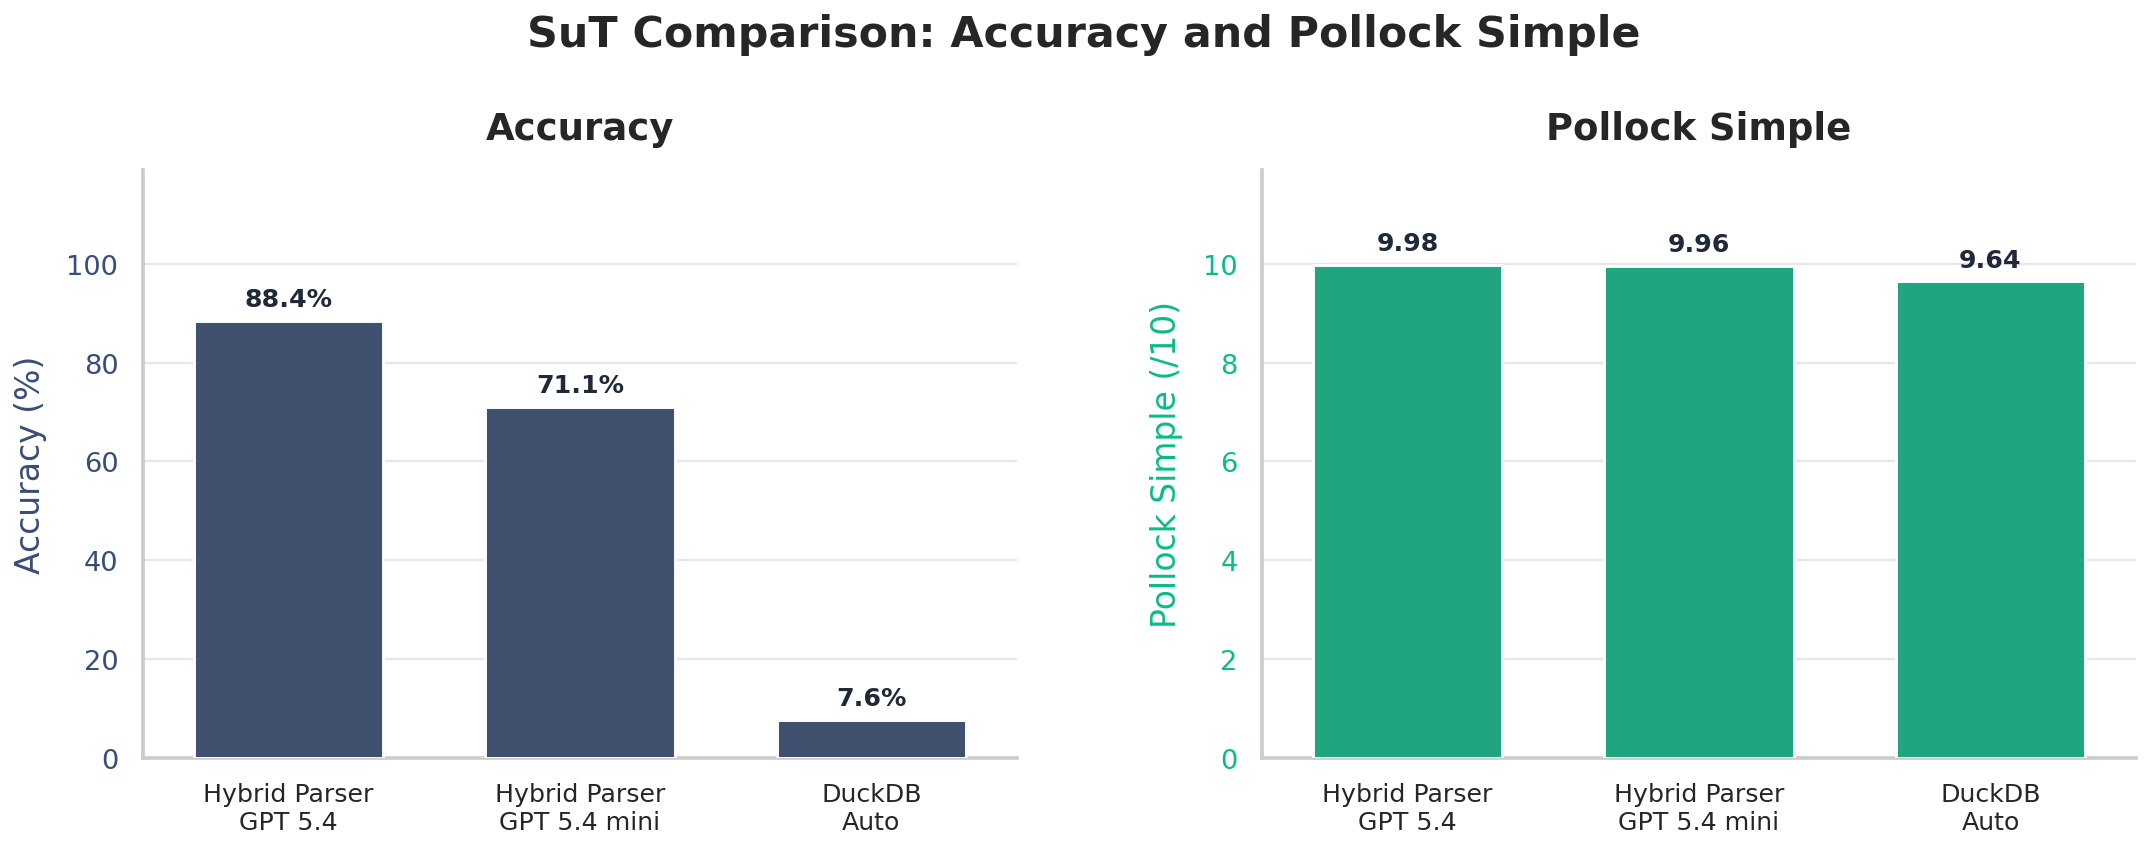

In [35]:
df = pd.DataFrame(
    {
        "SuT": [
            "Hybrid Parser\nGPT 5.4",
            "Hybrid Parser\nGPT 5.4 mini",
            "DuckDB\nAuto",
        ],
        "accuracy_pct": [
            88.3893,
            71.0607,
            7.6386,
        ],
        "pollock_simple": [
            9.975212,
            9.962150,
            9.645,
        ],
    }
)


fig, ax_accuracy, ax_pollock = plot_sut_comparison(df)

plt.show()

### Error Rates for Top 5 Best Performing SuTs

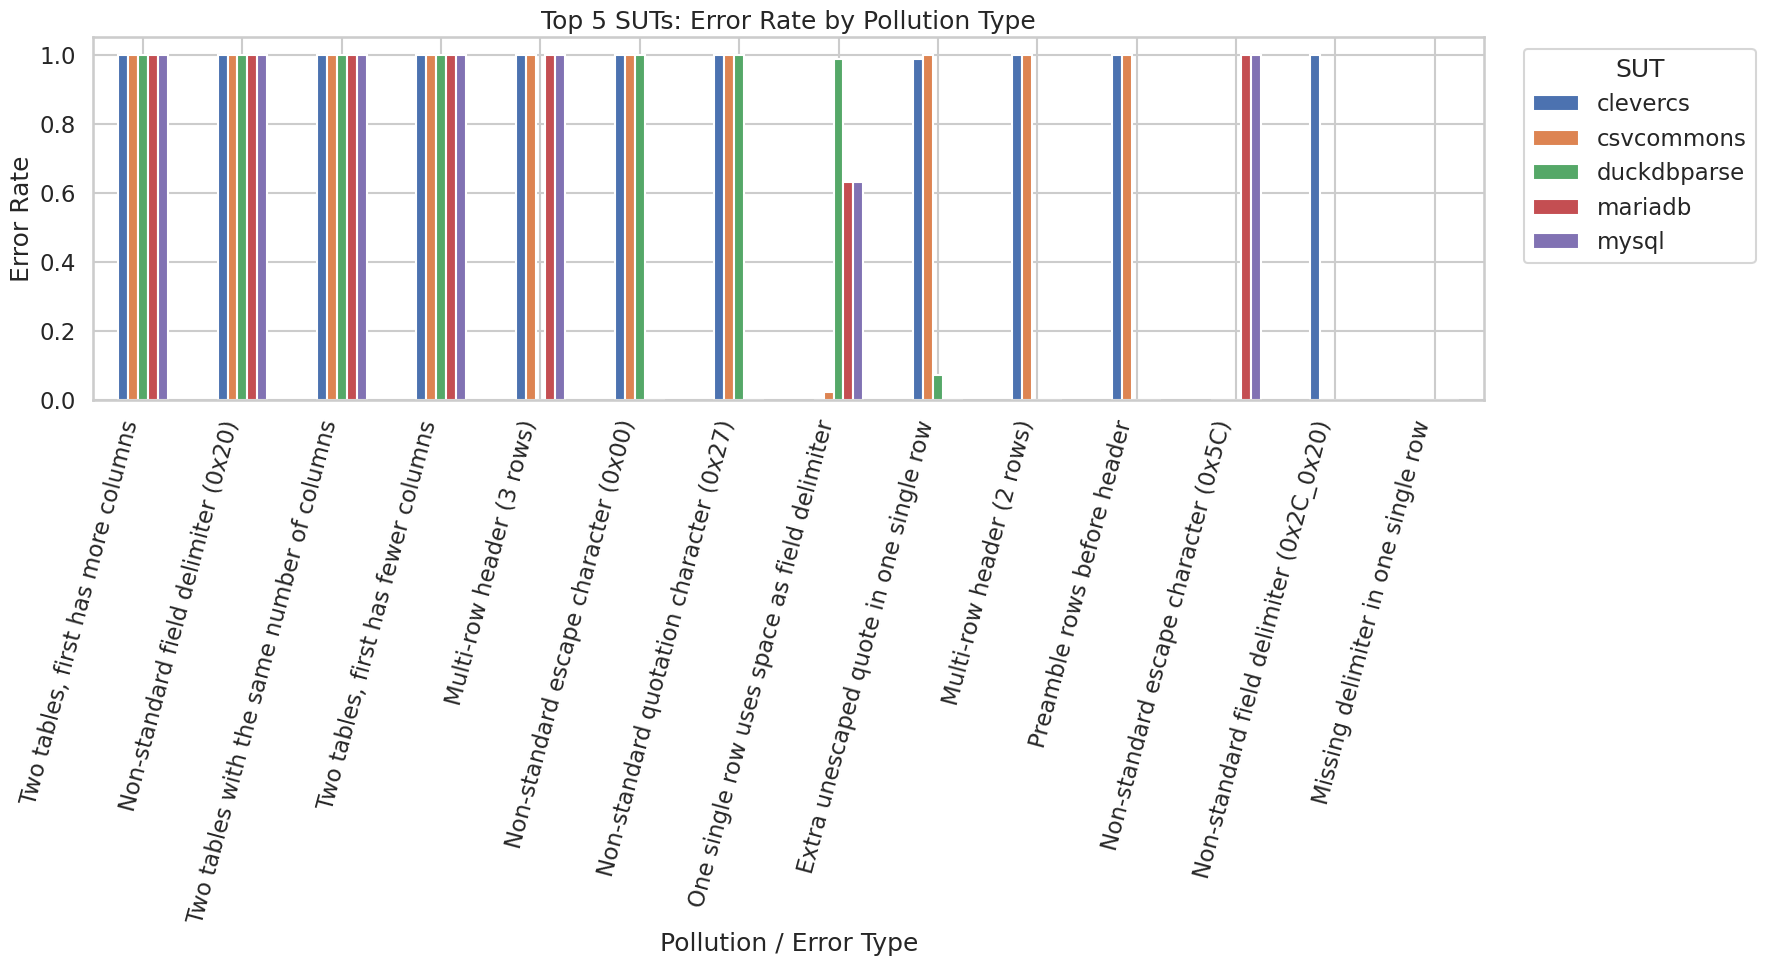

In [36]:
# Load CSV
df = pd.read_csv("../sut_error_summary.csv")

# Remove aggregate rows
df = df[df["pollution_group"] != "ALL"]

# -----------------------------------
# Select Top 5 SUTs
# -----------------------------------
top_suts = (
    df.groupby("sut")["error_rate"]
    .mean()
    .sort_values()
    .head(5)
    .index
)

df = df[df["sut"].isin(top_suts)]

# -----------------------------------
# Pivot table
# -----------------------------------
pivot = df.pivot_table(
    index="pollution_group",
    columns="sut",
    values="error_rate",
    aggfunc="mean"
)

# -----------------------------------
# Remove pollution groups with no errors
# (all values are 0)
# -----------------------------------
pivot = pivot[(pivot > 0).any(axis=1)]

# -----------------------------------
# Sort by average error severity
# -----------------------------------
pivot["mean_error"] = pivot.mean(axis=1)
pivot = pivot.sort_values("mean_error", ascending=False)
pivot = pivot.drop(columns="mean_error")

# -----------------------------------
# Plot
# -----------------------------------
ax = pivot.plot(
    kind="bar",
    figsize=(18, 10)
)

plt.title("Top 5 SUTs: Error Rate by Pollution Type")
plt.ylabel("Error Rate")
plt.xlabel("Pollution / Error Type")

plt.xticks(rotation=75, ha="right")

plt.legend(
    title="SUT",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
#plt.savefig("error_rate_by_pollution.png", dpi=300)
plt.show()

### Per System Error Analysis

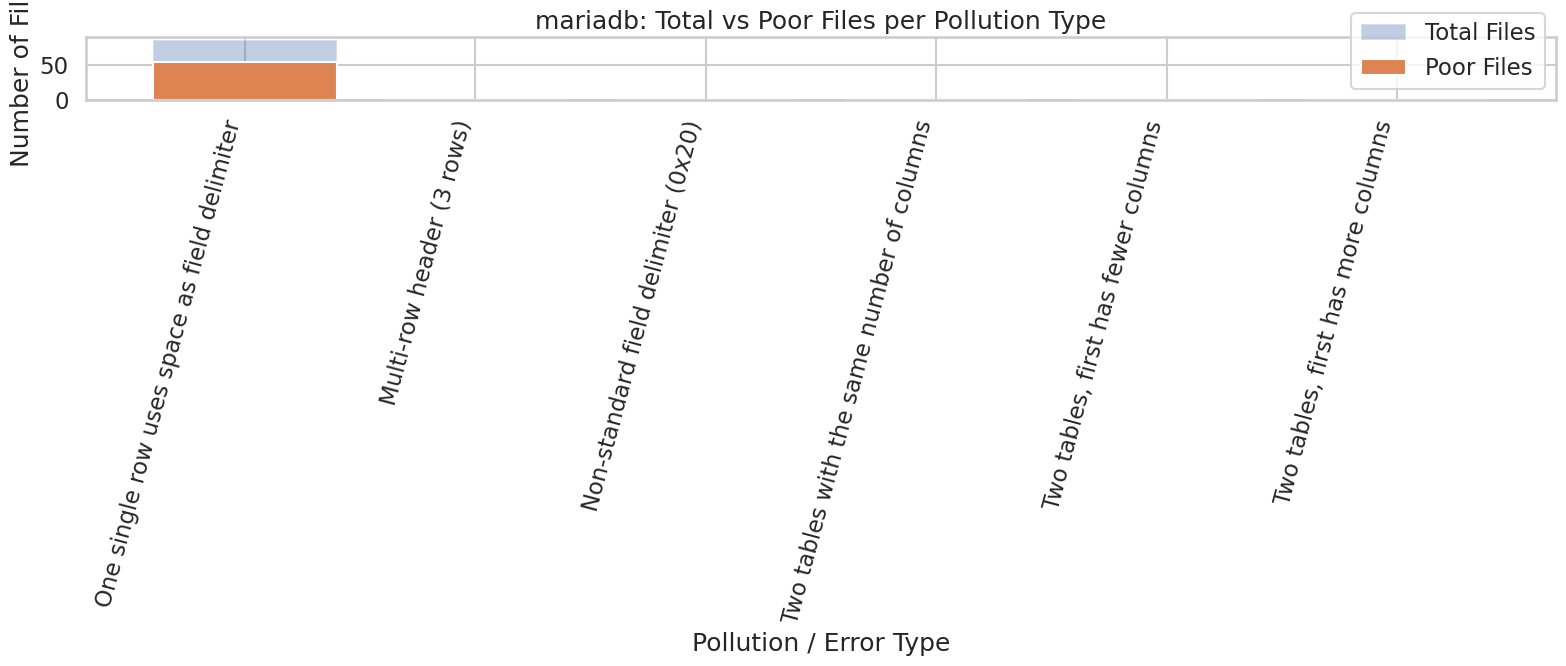

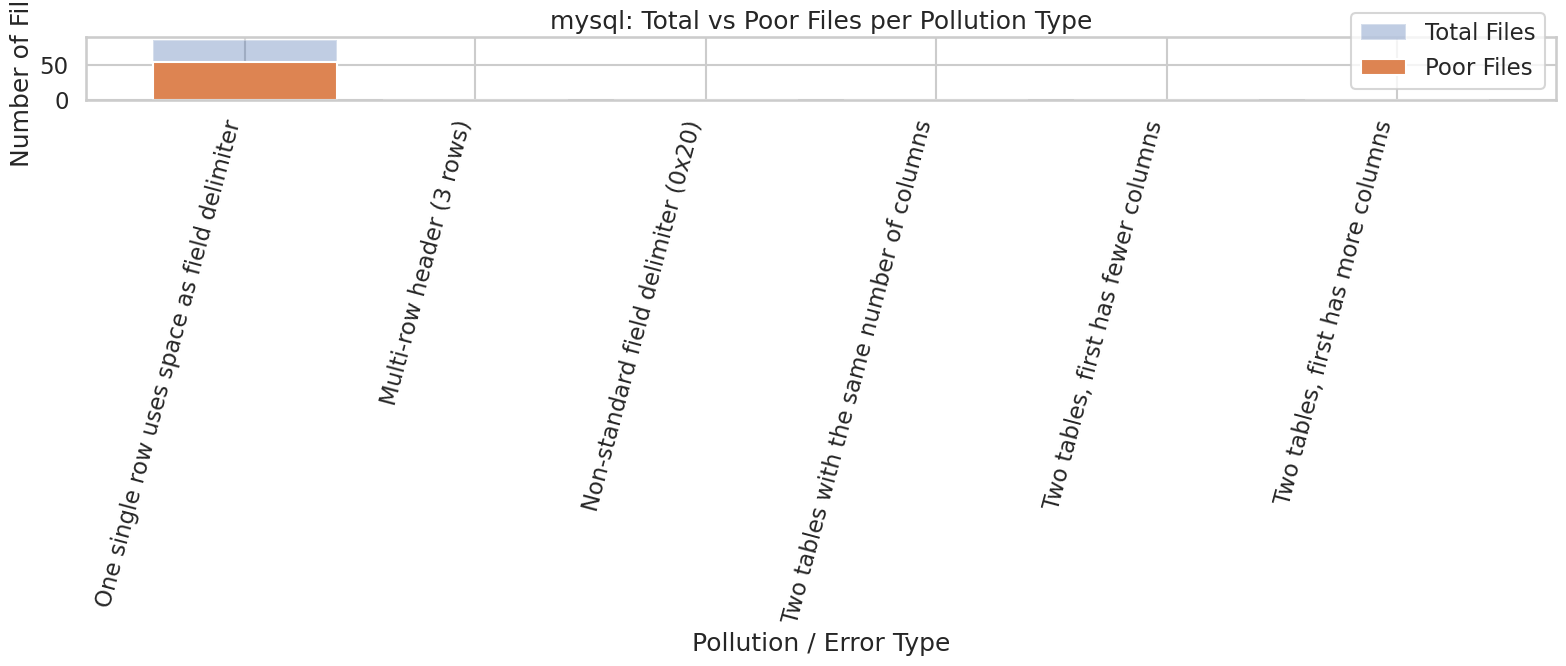

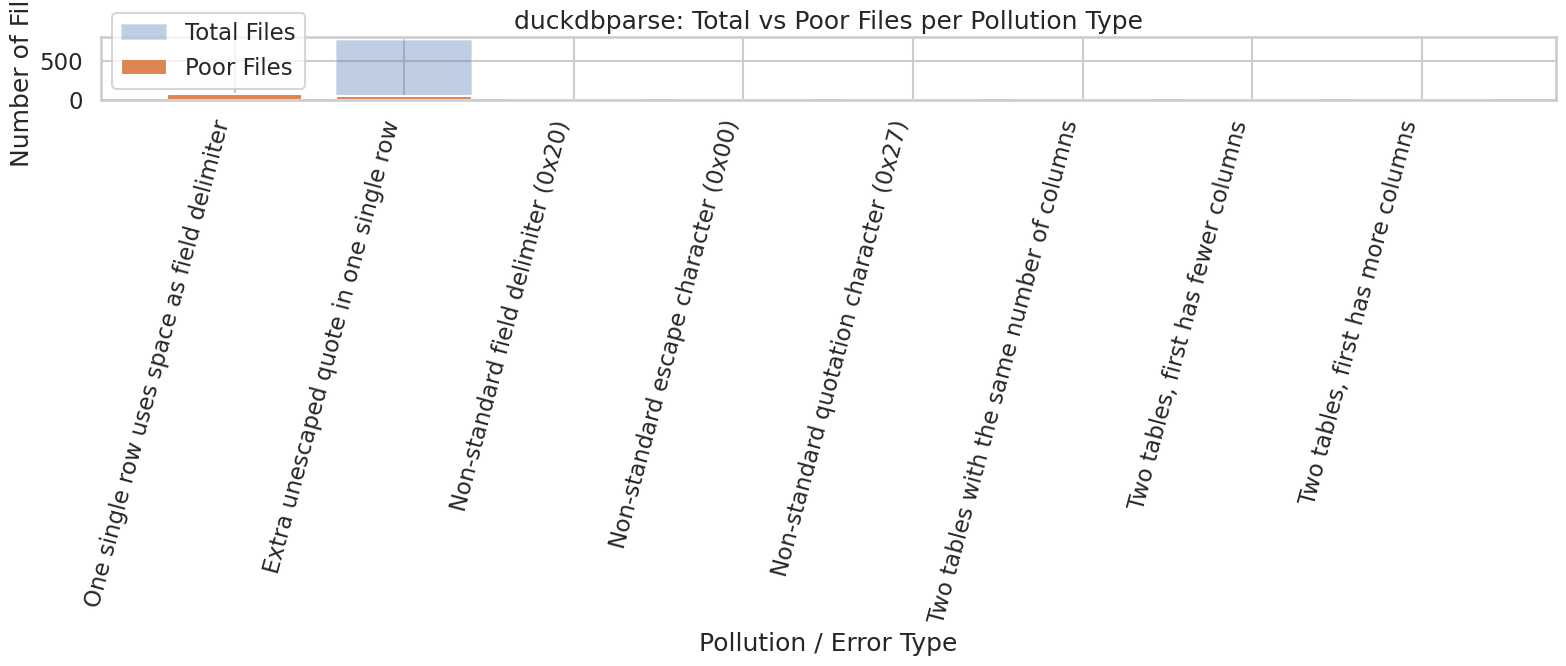

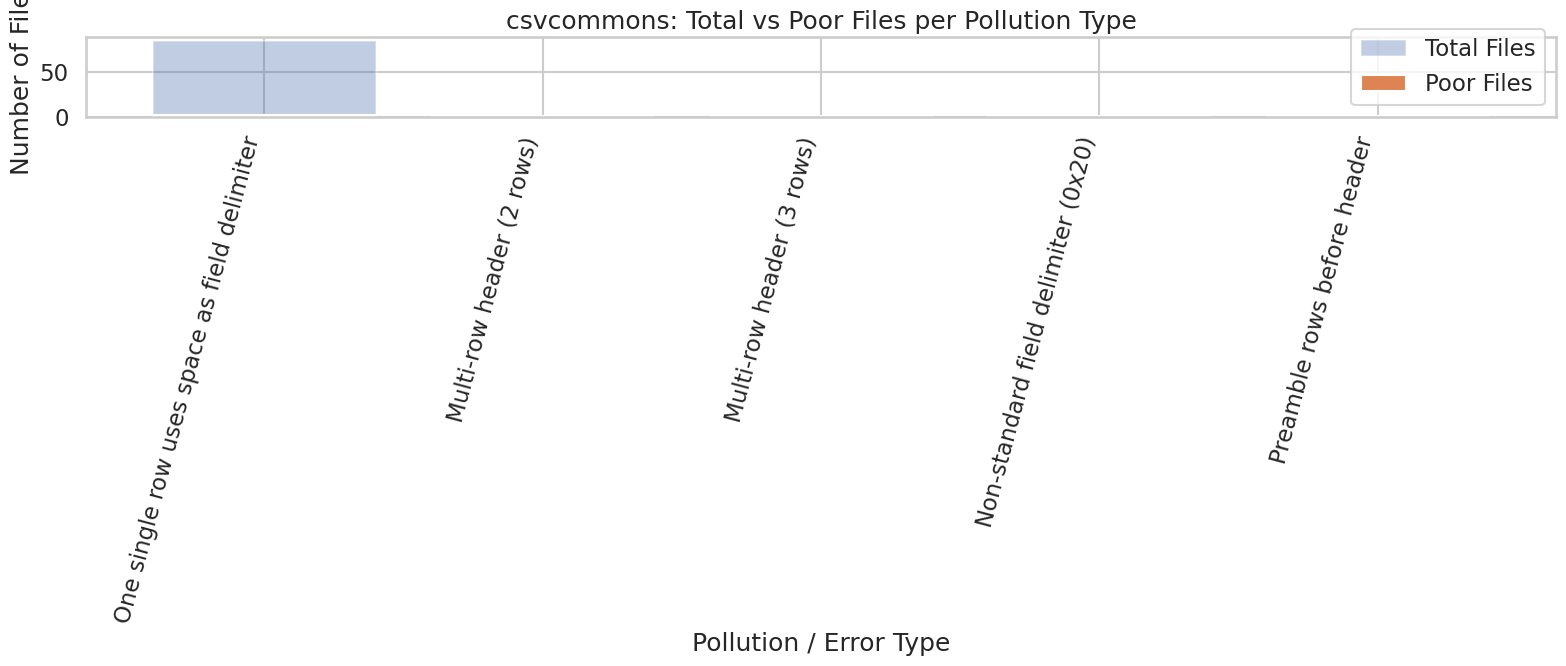

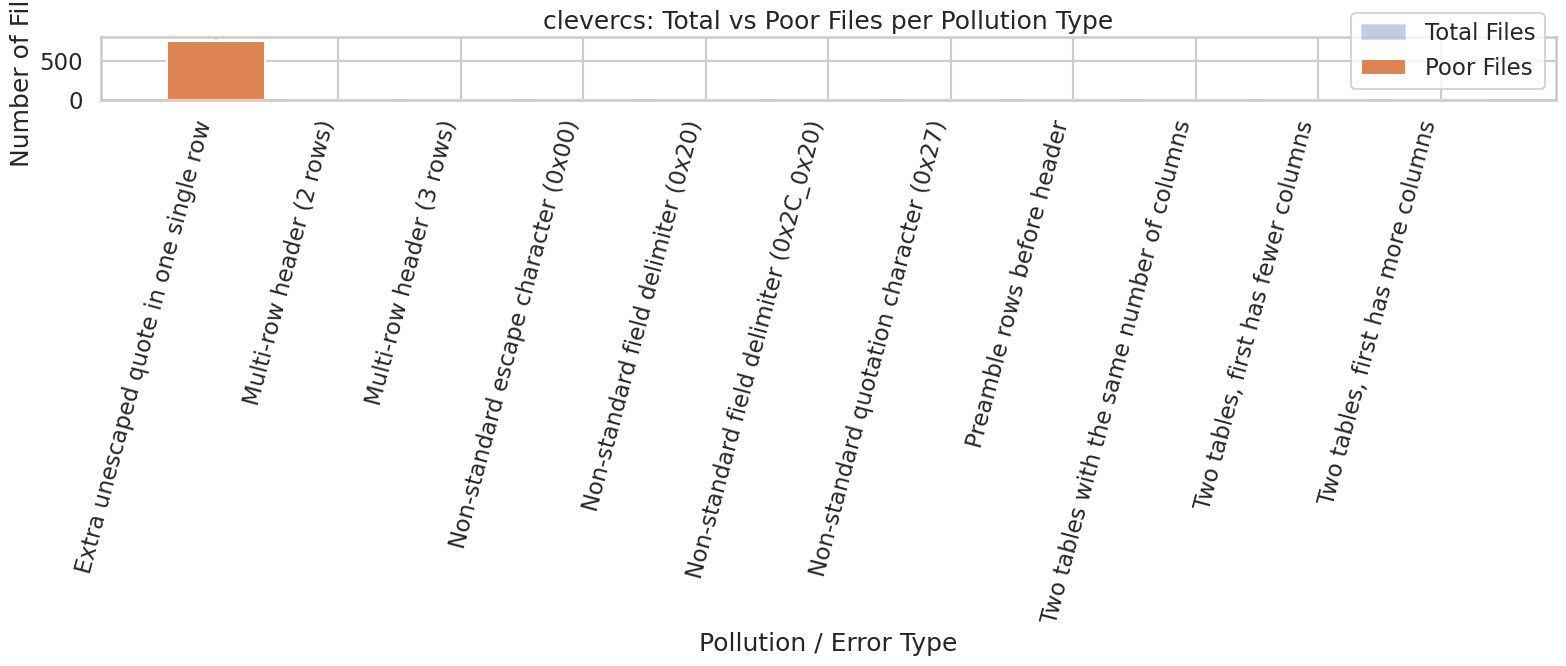

In [37]:
# Load CSV
df = pd.read_csv("../sut_error_summary.csv")

# Remove aggregate rows
df = df[df["pollution_group"] != "ALL"]

# -----------------------------------
# Select Top 5 SUTs
# -----------------------------------
top_suts = (
    df.groupby("sut")["error_rate"]
    .mean()
    .sort_values()
    .head(5)
    .index
)

df = df[df["sut"].isin(top_suts)]

# -----------------------------------
# Create one histogram per SUT
# -----------------------------------
for sut in top_suts:

    sut_df = df[df["sut"] == sut].copy()

    # Remove rows where there are no poor files
    sut_df = sut_df[sut_df["poor_files"] > 0]

    # Sort by number of poor files
    sut_df = sut_df.sort_values("poor_files", ascending=False)

    # X positions
    x = np.arange(len(sut_df))

    # Figure
    plt.figure(figsize=(16, 7))

    # Background bars = total files
    plt.bar(
        x,
        sut_df["total_files"],
        alpha=0.35,
        label="Total Files"
    )

    # Foreground bars = poor files
    plt.bar(
        x,
        sut_df["poor_files"],
        label="Poor Files"
    )

    # Labels
    plt.xticks(
        x,
        sut_df["pollution_group"],
        rotation=75,
        ha="right"
    )

    plt.ylabel("Number of Files")
    plt.xlabel("Pollution / Error Type")

    plt.title(f"{sut}: Total vs Poor Files per Pollution Type")

    plt.legend()

    plt.tight_layout()
    plt.show()

## Evaluation 2 - Statistics per Pollution Category

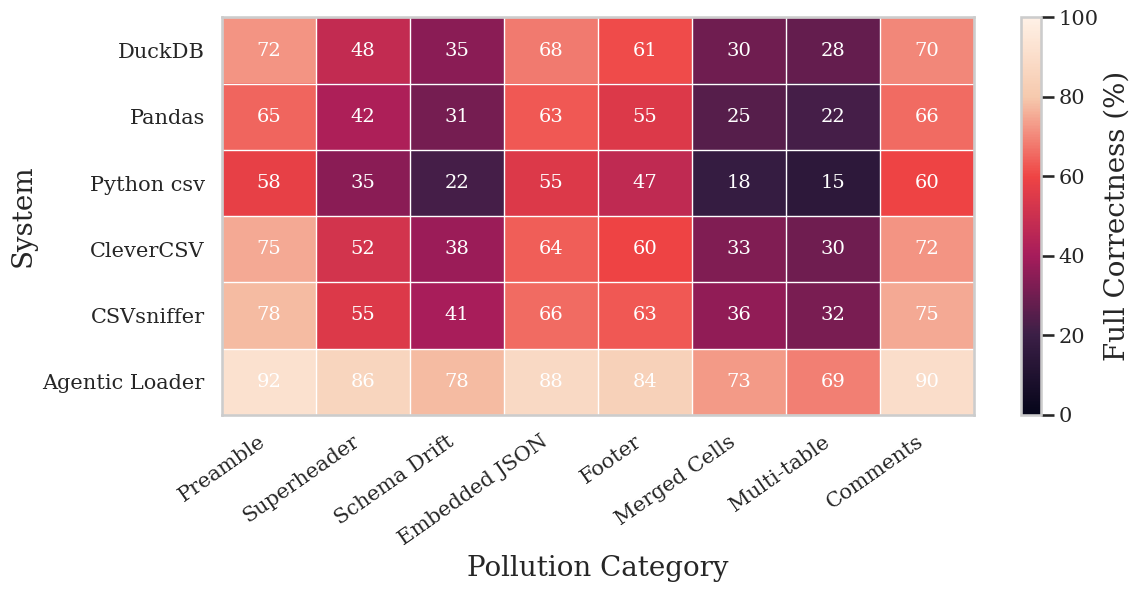

In [42]:
# Heatmap per Pollution Category and top-SUTs 

reddish_cmap = LinearSegmentedColormap.from_list(
    "paper_reddish",
    ["#05051a", "#3b1f46", "#a61c5b", "#ef4444", "#f6c9ad", "#fff1e6"]
)

# Optional but useful for a LaTeX-paper look.
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 16,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
})


#TODO: Change order of SuTs 

#TODO: Example data: replace with your actual results
systems = [
    "DuckDB",
    "Pandas",
    "Python csv",
    "CleverCSV",
    "CSVsniffer",
    "Agentic Loader"
]

pollutions = [
    "Preamble",
    "Superheader",
    "Schema Drift",
    "Embedded JSON",
    "Footer",
    "Merged Cells",
    "Multi-table",
    "Comments"
]

scores = np.array([
    [72, 48, 35, 68, 61, 30, 28, 70],
    [65, 42, 31, 63, 55, 25, 22, 66],
    [58, 35, 22, 55, 47, 18, 15, 60],
    [75, 52, 38, 64, 60, 33, 30, 72],
    [78, 55, 41, 66, 63, 36, 32, 75],
    [92, 86, 78, 88, 84, 73, 69, 90],
])

df = pd.DataFrame(scores, index=systems, columns=pollutions)

fig, ax = plt.subplots(figsize=(12, 6.2))

im = ax.imshow(
    df.values,
    cmap=reddish_cmap,
    aspect="auto",
    vmin=0,
    vmax=100
)

# Labels at cell centers
ax.set_xticks(np.arange(df.shape[1]))
ax.set_yticks(np.arange(df.shape[0]))
ax.set_xticklabels(pollutions, rotation=35, ha="right")
ax.set_yticklabels(systems)

# Grid at cell edges
ax.set_xticks(np.arange(-0.5, df.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, df.shape[0], 1), minor=True)

ax.grid(False)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

# Labels for axes and title
ax.set_xlabel("Pollution Category")
ax.set_ylabel("System")
#ax.set_title("Performance per Pollution Category")

# Cell annotations
for i in range(df.shape[0]):
    for j in range(df.shape[1]):
        value = df.iloc[i, j]

        # White text on dark cells, black on light cells
        color = "white" #if value > 60 else "black"

        ax.text(
            j, i,
            f"{value:.0f}",
            ha="center",
            va="center",
            color=color,
            fontsize=14
        )

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Full Correctness (%)")

plt.tight_layout()
plt.savefig("../CIDR_plots/error_heatmap.png", dpi=300)

In [39]:
# TODO: Table of Correct / False Passes per SuT per Semantic vs. Syntax Type

# Step 1 - save mapping of pollution to pollution category (see Google Table File)

# Step 2 - 

In [40]:
# TODO: 

## Evaluation 3 - Runtime and Cost Arguments

In [ ]:
# save current model cost per token for OpenAI models



In [ ]:
# Function that calculates cost per fun based on current rates and tokens used

def calc_openai_runcost(row, uncached_input_tokens, cached_input_tokens, completion_tokens):
    pass

In [5]:
# Path to your CSV file
csv_path = "/home/neubauer/src/pollock-offsite/results/full_llm_loader_naive/csv_storm/full_llm_loader_naive_time.csv"

# Load the CSV
df = pd.read_csv(csv_path)

# Display the first few rows
df.head()

,filename,time_0,uncached_input_tokens_0,cached_input_tokens_0,completion_tokens_0
0,file_metadata_as_header.csv,0.003502,462,5888,3000


In [ ]:
# Apply function to df

df.run_cost = ...


df["cost_usd"] = df.apply(
    calc_openai_runcost,
    axis=1,
    input_price=0.75,
    cached_input_price=0.075,
    output_price=4.50,
)

print(df[["filename", "cost_usd"]])
print(f"Total cost: ${df['cost_usd'].sum():.6f}")